📘 Baseline Models – Collaboration Notebook (Block Structure)

This notebook contains the shared project structure for our team.
Each block represents a specific functional part of the baseline models (A, B, C, D).
Team members should write their names next to the blocks they take responsibility for.

Please do not implement code in this file yet — each person will complete their own block in their own branch.

🔷 Block 0 – Imports & Setup

Assigned to: UNASSIGNED
Description:
Load standard libraries, PyTorch modules, timm, and utility functions.
Define device (CUDA/CPU).

In [1]:
import sys
print(sys.executable)

c:\Users\Elahe\Python\miniAnacoda\python.exe


In [ ]:
# ============ PYTORCH VERSION & CUDA CHECK ============
import torch                                 # Importiere PyTorch - die Haupt-Deep-Learning-Bibliothek
print(torch.__version__)                     # Zeige installierte PyTorch-Version (z.B. "2.1.0+cu121")
print("cuda:", torch.cuda.is_available())    # Prüfe ob NVIDIA GPU verfügbar ist (True/False)

2.6.0+cu124
cuda: True


In [ ]:
# Block 0 - Imports & Setup
# This block loads all required libraries and configures the environment

# ============ IMPORTS ============
import os                                    # Operating system utilities (file/folder operations)
import warnings                              # Control warning messages display
from torchvision import datasets, transforms, models  # Image datasets, preprocessing, pretrained models
from torch.utils.data import DataLoader      # Batch data loading for training
import torch                                 # Main PyTorch library
import torch.nn as nn                        # Neural network layers (Linear, Conv2d, etc.)
import torch.optim as optim                  # Optimizers (SGD, Adam, etc.)
import copy                                  # Deep copy for saving model weights
from pathlib import Path                     # Cross-platform file path handling
import random                                # Python random number generator
import numpy as np                           # Numerical computing library

# ============ CHECKPOINT PATH ============
FLOWER_CKPT = "../models/flower_resnet18_state.pth"  # Path to flower-pretrained weights (for Model C/D)

# ============ SET SEEDS FOR REPRODUCIBILITY ============
torch.manual_seed(42)                        # PyTorch random seed
np.random.seed(42)                           # NumPy random seed
random.seed(42)                              # Python random seed

# ============ cuDNN SETTINGS ============
torch.backends.cudnn.deterministic = True    # Ensure deterministic results (same output every run)
torch.backends.cudnn.benchmark = False       # Disable auto-tuning (slower but reproducible)

# ============ SELECT DEVICE ============
if torch.cuda.is_available():                # Check if NVIDIA GPU is available
    device = torch.device('cuda')            # Use GPU for faster training
    print("✅ CUDA GPU is available! Training on CUDA...")
else:
    device = torch.device('cpu')             # Fall back to CPU
    print("⚠️ No GPU found. Training on CPU...")

print("Using device:", device)               # Print selected device

# ============ SUPPRESS WARNINGS ============
warnings.filterwarnings("ignore", message=".*cuDNN.*")  # Hide cuDNN warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch.backends.cudnn")

✅ CUDA GPU is available! Training on CUDA...
Using device: cuda


🔷 Block 1 – Dataset & DataLoader Setup

Assigned to: UNASSIGNED
Description:

Define data transforms

Load ImageNetSubset dataset

Create dataloaders for train/val

Print class names, dataset sizes

In [ ]:
#Block 1 - Dataset & DataLoader Setup
# This block loads images and prepares them for training/validation

# ============ DEFINE PATHS ============
data_root = Path("data")                      # Root folder containing all data
imagenet_root = data_root / "ImageNetSubset"  # Subfolder with ImageNet-style structure
train_dir = imagenet_root / "train"           # Training images folder
val_dir = imagenet_root / "val"               # Validation images folder

# ============ IMAGE SIZE ============
input_size = 224  # ResNet-18 expects 224x224 pixel images

# ============ DATA TRANSFORMS ============
# Transforms are preprocessing steps applied to each image
data_transforms = {
    # Training transforms (with augmentation for better generalization)
    "train": transforms.Compose([
        transforms.Resize((input_size, input_size)),  # Resize image to 224x224
        transforms.RandomHorizontalFlip(),             # Randomly flip image left-right (50% chance)
        transforms.RandomRotation(15),                 # Randomly rotate image by ±15 degrees
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),   # Randomly change brightness, contrast, saturation, hue
        transforms.ToTensor(),                         # Convert PIL image to PyTorch tensor (0-255 → 0-1)
        transforms.Normalize([0.485, 0.456, 0.406],   # Normalize using ImageNet mean values (RGB)
                             [0.229, 0.224, 0.225]),  # Normalize using ImageNet std values (RGB)
    ]),
    # Validation transforms (NO augmentation - evaluate on clean images)
    "val": transforms.Compose([
        transforms.Resize((input_size, input_size)),  # Resize image to 224x224
        transforms.ToTensor(),                         # Convert to tensor
        transforms.Normalize([0.485, 0.456, 0.406],   # Same normalization as training
                             [0.229, 0.224, 0.225]),
    ]),
}

# ============ HELPER FUNCTION ============
def has_images(directory: Path):
    """Check if a directory contains any JPG/JPEG images"""
    if not directory.exists():        # If folder doesn't exist, return False
        return False
    valid_extensions = {".jpg", ".jpeg", ".JPG", ".JPEG"}  # Accepted file types
    for f in directory.rglob("*"):    # Search all files recursively
        if f.suffix.lower() in valid_extensions:  # Check file extension
            return True               # Found at least one image
    return False                      # No images found

# ============ LOAD DATASET ============
# Check if real images exist, otherwise use fake data for testing
if has_images(train_dir) and has_images(val_dir):
    # Real dataset found - use ImageFolder
    print("✅ Using real ImageNetSubset dataset (ImageFolder)")

    image_datasets = {
        # ImageFolder automatically assigns labels based on subfolder names
        "train": datasets.ImageFolder(train_dir, data_transforms["train"]),
        "val": datasets.ImageFolder(val_dir, data_transforms["val"]),
    }
    num_classes = len(image_datasets["train"].classes)  # Count number of class folders
    class_names = image_datasets["train"].classes       # Get list of class names

else:
    # No real data - use FakeData for pipeline testing
    print("⚠️ No real dataset found. Using FakeData for pipeline validation.")

    num_classes = 10                                    # Simulate 10 classes
    class_names = [f"class_{i}" for i in range(num_classes)]  # Generate fake class names
    image_datasets = {
        "train": datasets.FakeData(
            size=64,                                    # 64 fake training samples
            image_size=(3, input_size, input_size),    # 3 channels (RGB), 224x224
            num_classes=num_classes,                   # 10 classes
            transform=data_transforms["train"],        # Apply training transforms
        ),
        "val": datasets.FakeData(
            size=32,                                    # 32 fake validation samples
            image_size=(3, input_size, input_size),
            num_classes=num_classes,
            transform=data_transforms["val"],          # Apply validation transforms
        ),
    }

# ============ CREATE DATALOADERS ============
batch_size = 32   # Number of images per batch (GPU processes 32 images at once)

# num_workers = number of parallel processes for data loading
# 0 = load data in main process (most stable for notebooks)
num_workers = 0

dataloader = {
    # Training DataLoader - shuffle=True randomizes order each epoch
    "train": DataLoader(
        image_datasets["train"],
        batch_size=batch_size,
        shuffle=True,           # Shuffle training data for better learning
        num_workers=num_workers
    ),
    # Validation DataLoader - shuffle=False keeps order consistent
    "val": DataLoader(
        image_datasets["val"],
        batch_size=batch_size,
        shuffle=False,          # No shuffle for validation (reproducible results)
        num_workers=num_workers
    ),
}

# ============ PRINT SUMMARY ============
print("Train samples:", len(image_datasets["train"]))  # Total training images
print("Val samples:", len(image_datasets["val"]))      # Total validation images
print("Num classes:", num_classes)                     # Number of categories
print("Classes:", class_names)                         # List of class names

✅ Using real ImageNetSubset dataset (ImageFolder)
Train samples: 13000
Val samples: 500
Num classes: 10
Classes: ['binder', 'coffee_mug', 'computer_keyboard', 'mouse', 'notebook', 'remote_control', 'soup_bowl', 'teapot', 'toilet_tissue', 'wooden_spoon']


🔷 Block 2 – Training Function (train_model)

Assigned to: UNASSIGNED
Description:
Provide a reusable training loop supporting:

train & eval mode

loss/acc tracking

saving best checkpoint

printing epoch results

This function will be shared by Models A, B, C, D.

In [ ]:
 Block 2 - Training Function
# This function trains any model and returns the best version based on validation accuracy

def train_model(
    model,                                   # The neural network model to train
    train_loader,                            # DataLoader for training data
    val_loader,                              # DataLoader for validation data
    device,                                  # 'cuda' or 'cpu'
    num_epochs,                              # Number of training epochs
    lr=1e-4,                                 # Learning rate (default: 0.0001)
    save_path="../models/best_model.pth",   # Path to save best model weights
):
    """
    Generic training loop for a classification model.
    Returns: model, best_acc, history
    """
    
    # ============ SETUP ============
    model = model.to(device)                 # Move model to GPU/CPU
    criterion = nn.CrossEntropyLoss()        # Loss function for classification
    
    optimizer = optim.SGD(                   # SGD optimizer with momentum
        filter(lambda p: p.requires_grad, model.parameters()),  # Only trainable params
        lr=lr,                               # Learning rate
        momentum=0.9,                        # Momentum for faster convergence
    )

    dataset_sizes = {                        # Store dataset sizes for averaging
        "train": len(train_loader.dataset),
        "val": len(val_loader.dataset),
    }

    best_acc = 0.0                           # Track best validation accuracy
    best_state = copy.deepcopy(model.state_dict())  # Save initial weights

    history = {                              # Store metrics for plotting
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    # ============ TRAINING LOOP ============
    for epoch in range(num_epochs):          # Loop through epochs
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ======== TRAIN PHASE ========
        model.train()                        # Set model to training mode (enables dropout, batchnorm)
        running_loss = 0.0                   # Accumulate loss for this epoch
        running_corrects = 0                 # Accumulate correct predictions

        for inputs, labels in train_loader:  # Loop through batches
            inputs = inputs.to(device)       # Move images to GPU/CPU
            labels = labels.to(device)       # Move labels to GPU/CPU

            optimizer.zero_grad(set_to_none=True)  # Clear previous gradients

            outputs = model(inputs)          # Forward pass: get predictions
            loss = criterion(outputs, labels)  # Calculate loss
            _, preds = torch.max(outputs, 1)  # Get predicted class (highest score)

            loss.backward()                  # Backward pass: compute gradients
            optimizer.step()                 # Update weights

            running_loss += loss.item() * inputs.size(0)  # Accumulate weighted loss
            running_corrects += (preds == labels).sum().item()  # Count correct predictions

        # Calculate epoch averages
        train_epoch_loss = running_loss / dataset_sizes["train"]
        train_epoch_acc = running_corrects / dataset_sizes["train"]
        history["train_loss"].append(train_epoch_loss)
        history["train_acc"].append(train_epoch_acc)

        print(f"train  Loss: {train_epoch_loss:.4f}  Acc: {train_epoch_acc:.4f}")

        # ======== VALIDATION PHASE ========
        model.eval()                         # Set model to evaluation mode (disables dropout)
        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():                # Disable gradient computation (faster, saves memory)
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)      # Forward pass only (no backprop)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()

        # Calculate validation averages
        val_epoch_loss = running_loss / dataset_sizes["val"]
        val_epoch_acc = running_corrects / dataset_sizes["val"]
        history["val_loss"].append(val_epoch_loss)
        history["val_acc"].append(val_epoch_acc)

        print(f"val    Loss: {val_epoch_loss:.4f}  Acc: {val_epoch_acc:.4f}")

        # ======== SAVE BEST MODEL ========
        if val_epoch_acc > best_acc:         # If this epoch is the best so far
            best_acc = val_epoch_acc         # Update best accuracy
            best_state = copy.deepcopy(model.state_dict())  # Save weights
            torch.save(best_state, save_path)  # Save to disk
            print(f"  ↳ New best! Saved to {save_path}")

    # ============ FINISH ============
    print(f"\nBest val Acc: {best_acc:.4f}")
    model.load_state_dict(best_state)        # Load best weights into model

    return model, best_acc, history          # Return trained model and metrics

print("✅ train_model() function defined successfully.")#

✅ train_model() function defined successfully.


🔷 Block 3 – Flower Pretrained Backbone Explanation

Assigned to: UNASSIGNED
Description:
Document how flower_resnet18_state.pth was created using train_flower_pretrain.py, including:

Dataset (Oxford Flowers 102)

Training approach

Extracting backbone weights (removing fc layer)

This block does not need training code — only explanation.

In [7]:
#Block 3

🔷 Block 4 – Model A (ImageNet Pretrained, Backbone Frozen)

Assigned to: UNASSIGNED
Description:

Create ResNet-18 with ImageNet weights

Replace final fc layer

Freeze backbone

Train & report accuracy

Represents a linear probe baseline.

In [ ]:
# Block 4 - Model A (ImageNet Pretrained, Backbone Frozen)
# This model uses pretrained ImageNet weights but only trains the final layer (Linear Probing)

from torchvision.models import ResNet18_Weights  # Import pretrained weight options

def create_model_A(num_classes):
    """
    Model A: Linear Probing
    - Use pretrained ResNet-18 backbone (frozen)
    - Only train the new classification layer
    """
    
    # ============ STEP 1: LOAD PRETRAINED MODEL ============
    weights = ResNet18_Weights.IMAGENET1K_V1   # Use ImageNet-1K pretrained weights (version 1)
    model = models.resnet18(weights=weights)   # Load ResNet-18 with these weights

    # ============ STEP 2: REPLACE CLASSIFIER ============
    in_features = model.fc.in_features         # Get input size of original fc layer (512 for ResNet-18)
    model.fc = nn.Linear(in_features, num_classes)  # Replace fc: 512 → num_classes (10)

    # ============ STEP 3: FREEZE BACKBONE ============
    for name, param in model.named_parameters():  # Loop through all parameters
        if not name.startswith("fc."):         # If parameter is NOT in fc layer
            param.requires_grad = False        # Freeze it (no gradient updates)
    # Result: Only fc.weight and fc.bias are trainable (~5,130 params)
    # Backbone (~11M params) stays frozen with ImageNet features

    print("Model A: ImageNet-pretrained backbone frozen (linear probe).")
    return model.to(device)                    # Move model to GPU/CPU

print("✅ create_model_A() function defined successfully.")

✅ create_model_A() function defined successfully.


🔷 Block 5 – Model B (ImageNet Pretrained, Full Fine-Tuning)

Assigned to: UNASSIGNED
Description:

Same architecture as Model A

But do not freeze backbone

Train and compare against Model A

Represents a fine-tuned baseline.

In [ ]:
# Block 5 - Model B (ImageNet Pretrained, Full Fine-Tuning)
# This model uses pretrained ImageNet weights and trains ALL layers (Fine-Tuning)

def create_model_B(num_classes):
    """
    Model B: Full Fine-Tuning
    - Use pretrained ResNet-18 backbone (trainable)
    - Train the entire network including backbone
    """
    
    # ============ STEP 1: LOAD PRETRAINED MODEL ============
    weights = ResNet18_Weights.IMAGENET1K_V1   # Use ImageNet-1K pretrained weights
    model = models.resnet18(weights=weights)   # Load ResNet-18 with these weights

    # ============ STEP 2: REPLACE CLASSIFIER ============
    in_features = model.fc.in_features         # Get input size of original fc layer (512)
    model.fc = nn.Linear(in_features, num_classes)  # Replace fc: 512 → num_classes (10)

    # ============ STEP 3: UNFREEZE ALL LAYERS ============
    for name, param in model.named_parameters():  # Loop through all parameters
        param.requires_grad = True             # Make ALL parameters trainable
    # Result: All ~11M parameters are trainable
    # Backbone adapts to new task (can learn task-specific features)
    # Requires smaller learning rate to avoid destroying pretrained features

    print("Model B: ImageNet-pretrained backbone trainable (fine-tuning).")
    return model.to(device)                    # Move model to GPU/CPU

print("✅ create_model_B() function defined successfully.")

✅ create_model_B() function defined successfully.


C:\Users\Elahe\AppData\Local\Temp\ipykernel_23432\1889273310.py:81: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Elahe\AppData\Local\Temp\ipykernel_23432\1889273310.py:82: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig("model_A_vs_B_architecture.png", dpi=200, bbox_inches='tight')
c:\Users\Elahe\Python\miniAnacoda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


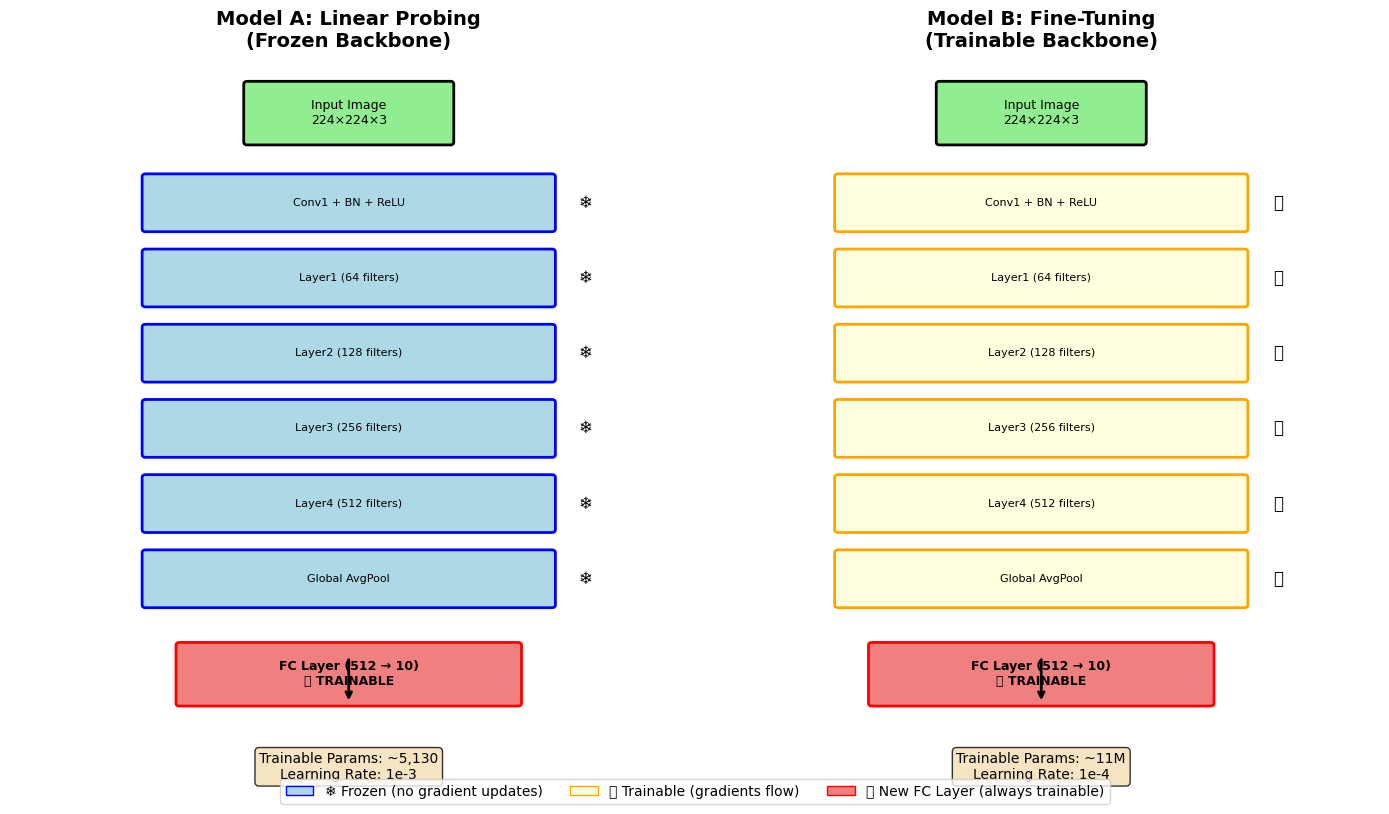

✅ Diagram saved as 'model_A_vs_B_architecture.png'


In [1]:
# Visualization: Model A vs Model B Architecture Comparison
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# ============ MODEL A (Linear Probing) ============
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 12)
ax1.set_title("Model A: Linear Probing\n(Frozen Backbone)", fontsize=14, fontweight='bold')
ax1.axis('off')

# Input
ax1.add_patch(mpatches.FancyBboxPatch((3.5, 10.5), 3, 1, boxstyle="round,pad=0.05", 
                                       facecolor='lightgreen', edgecolor='black', linewidth=2))
ax1.text(5, 11, "Input Image\n224×224×3", ha='center', va='center', fontsize=9)

# Frozen backbone layers (blue = frozen)
layers = ["Conv1 + BN + ReLU", "Layer1 (64 filters)", "Layer2 (128 filters)", 
          "Layer3 (256 filters)", "Layer4 (512 filters)", "Global AvgPool"]
for i, layer in enumerate(layers):
    y = 9 - i * 1.3
    ax1.add_patch(mpatches.FancyBboxPatch((2, y), 6, 0.9, boxstyle="round,pad=0.05",
                                           facecolor='lightblue', edgecolor='blue', linewidth=2))
    ax1.text(5, y + 0.45, layer, ha='center', va='center', fontsize=8)
    ax1.text(8.5, y + 0.45, "❄️", ha='center', va='center', fontsize=12)

# FC layer (green = trainable)
ax1.add_patch(mpatches.FancyBboxPatch((2.5, 0.8), 5, 1, boxstyle="round,pad=0.05",
                                       facecolor='lightcoral', edgecolor='red', linewidth=2))
ax1.text(5, 1.3, "FC Layer (512 → 10)\n🔥 TRAINABLE", ha='center', va='center', fontsize=9, fontweight='bold')

# Arrow
ax1.annotate('', xy=(5, 0.8), xytext=(5, 1.6), arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Stats
ax1.text(5, -0.3, "Trainable Params: ~5,130\nLearning Rate: 1e-3", ha='center', va='center', 
         fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# ============ MODEL B (Fine-Tuning) ============
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 12)
ax2.set_title("Model B: Fine-Tuning\n(Trainable Backbone)", fontsize=14, fontweight='bold')
ax2.axis('off')

# Input
ax2.add_patch(mpatches.FancyBboxPatch((3.5, 10.5), 3, 1, boxstyle="round,pad=0.05",
                                       facecolor='lightgreen', edgecolor='black', linewidth=2))
ax2.text(5, 11, "Input Image\n224×224×3", ha='center', va='center', fontsize=9)

# Trainable backbone layers (coral = trainable)
for i, layer in enumerate(layers):
    y = 9 - i * 1.3
    ax2.add_patch(mpatches.FancyBboxPatch((2, y), 6, 0.9, boxstyle="round,pad=0.05",
                                           facecolor='lightyellow', edgecolor='orange', linewidth=2))
    ax2.text(5, y + 0.45, layer, ha='center', va='center', fontsize=8)
    ax2.text(8.5, y + 0.45, "🔥", ha='center', va='center', fontsize=12)

# FC layer (also trainable)
ax2.add_patch(mpatches.FancyBboxPatch((2.5, 0.8), 5, 1, boxstyle="round,pad=0.05",
                                       facecolor='lightcoral', edgecolor='red', linewidth=2))
ax2.text(5, 1.3, "FC Layer (512 → 10)\n🔥 TRAINABLE", ha='center', va='center', fontsize=9, fontweight='bold')

# Arrow
ax2.annotate('', xy=(5, 0.8), xytext=(5, 1.6), arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Stats
ax2.text(5, -0.3, "Trainable Params: ~11M\nLearning Rate: 1e-4", ha='center', va='center',
         fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Legend
legend_elements = [
    mpatches.Patch(facecolor='lightblue', edgecolor='blue', label='❄️ Frozen (no gradient updates)'),
    mpatches.Patch(facecolor='lightyellow', edgecolor='orange', label='🔥 Trainable (gradients flow)'),
    mpatches.Patch(facecolor='lightcoral', edgecolor='red', label='🔥 New FC Layer (always trainable)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("model_A_vs_B_architecture.png", dpi=200, bbox_inches='tight')
plt.show()

print("✅ Diagram saved as 'model_A_vs_B_architecture.png'")

🔷 Block 6 – Model C (Flower Pretrained, Backbone Frozen)

Assigned to: UNASSIGNED
Description:

Load ResNet-18

Load flower-pretrained weights (exclude fc)

Replace fc with household classifier

Freeze backbone

Train & compare to Model A

Tests whether flower pretraining provides better initialization than ImageNet.

In [ ]:
# Block 6 - Model C (Flower Pretrained, Backbone Frozen)
# This model uses flower-pretrained weights but only trains the final layer (Linear Probing)

def create_model_C(num_classes):
    """
    Model C: Linear Probing with Flower Pretrained Weights
    - Use ResNet-18 backbone pretrained on flower dataset
    - Only train the new classification layer (fc)
    """
    
    # ============ STEP 1: CREATE EMPTY MODEL ============
    model = models.resnet18(weights=None)      # Create ResNet-18 without any pretrained weights

    # ============ STEP 2: LOAD FLOWER CHECKPOINT ============
    raw_state = torch.load(FLOWER_CKPT, map_location="cpu")  # Load saved weights from disk

    # Handle 'module.' prefix (appears when model was saved with DataParallel/multi-GPU)
    if any(k.startswith("module.") for k in raw_state.keys()):
        # Remove 'module.' prefix from all keys
        state = {k.replace("module.", "", 1): v for k, v in raw_state.items()}
    else:
        state = raw_state                      # No prefix, use weights as-is

    # ============ STEP 3: LOAD BACKBONE ONLY ============
    # Remove fc layer weights - we want fresh fc for our task
    state_no_fc = {k: v for k, v in state.items() if not k.startswith("fc.")}
    
    # Load weights with strict=False (allows missing keys)
    missing, unexpected = model.load_state_dict(state_no_fc, strict=False)

    print("Loaded flower-pretrained backbone (without fc).")
    print("Missing keys:", missing)            # Expected: ['fc.weight', 'fc.bias']
    print("Unexpected keys:", unexpected)      # Expected: [] (empty)

    # ============ STEP 4: REPLACE CLASSIFIER ============
    in_features = model.fc.in_features         # Get input size of original fc layer (512)
    model.fc = nn.Linear(in_features, num_classes)  # Replace fc: 512 → num_classes (10)

    # ============ STEP 5: FREEZE BACKBONE ============
    for name, param in model.named_parameters():  # Loop through all parameters
        if not name.startswith("fc."):         # If parameter is NOT in fc layer
            param.requires_grad = False        # Freeze it (no gradient updates)
    # Result: Only fc.weight and fc.bias are trainable (~5,130 params)
    # Flower-pretrained backbone stays frozen

    print("Model C: Flower-pretrained backbone frozen (linear probe).")
    return model.to(device)                    # Move model to GPU/CPU

print("✅ create_model_C() function defined successfully.")

✅ create_model_C() function defined successfully.


🔷 Block 7 – Model D (Flower Pretrained, Full Fine-Tuning)

Assigned to: UNASSIGNED
Description:

Same as Model C

Backbone is trainable

Train & compare to Model B

In [ ]:
# Block 7 - Model D (Flower Pretrained, Full Fine-Tuning)
# This model uses flower-pretrained weights and trains ALL layers (Fine-Tuning)

def create_model_D(num_classes):
    """
    Model D: Full Fine-Tuning with Flower Pretrained Weights
    - Use ResNet-18 backbone pretrained on flower dataset
    - Train the entire network including backbone
    """
    
    # ============ STEP 1: CREATE EMPTY MODEL ============
    model = models.resnet18(weights=None)      # Create ResNet-18 without any pretrained weights

    # ============ STEP 2: LOAD FLOWER CHECKPOINT ============
    raw_state = torch.load(FLOWER_CKPT, map_location="cpu")  # Load saved weights from disk

    # Handle 'module.' prefix (appears when model was saved with DataParallel/multi-GPU)
    if any(k.startswith("module.") for k in raw_state.keys()):
        # Remove 'module.' prefix from all keys
        state = {k.replace("module.", "", 1): v for k, v in raw_state.items()}
    else:
        state = raw_state                      # No prefix, use weights as-is

    # ============ STEP 3: LOAD BACKBONE ONLY ============
    # Remove fc layer weights - we want fresh fc for our task
    state_no_fc = {k: v for k, v in state.items() if not k.startswith("fc.")}
    
    # Load weights with strict=False (allows missing keys)
    missing, unexpected = model.load_state_dict(state_no_fc, strict=False)

    print("Loaded flower-pretrained backbone (without fc).")
    print("Missing keys:", missing)            # Expected: ['fc.weight', 'fc.bias']
    print("Unexpected keys:", unexpected)      # Expected: [] (empty)

    # ============ STEP 4: REPLACE CLASSIFIER ============
    in_features = model.fc.in_features         # Get input size of original fc layer (512)
    model.fc = nn.Linear(in_features, num_classes)  # Replace fc: 512 → num_classes (10)

    # ============ STEP 5: UNFREEZE ALL LAYERS ============
    for name, param in model.named_parameters():  # Loop through all parameters
        param.requires_grad = True             # Make ALL parameters trainable
    # Result: All ~11M parameters are trainable
    # Flower-pretrained backbone adapts to new task
    # Requires smaller learning rate to avoid destroying pretrained features

    print("Model D: Flower-pretrained backbone trainable (fine-tuning).")
    return model.to(device)                    # Move model to GPU/CPU

print("✅ create_model_D() function defined successfully.")

✅ create_model_D() function defined successfully.


In [ ]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [11]:
# Prüfe deine GPU-Architektur
import torch
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))  # z.B. (8, 6) = sm_86

NVIDIA GeForce RTX 5060 Ti
(12, 0)


🔷 Block 8 – Comparison, Plots & Final Discussion

Assigned to: UNASSIGNED
Description:
Summarize results across Models A–D:

Table of accuracies

Discussion of differences

Insights: transferability from ImageNet vs. Flowers

In [12]:
# Block 8 - Training & Comparison (Quick Test Version)
# This block trains Model A with CUDA error handling and fallback to CPU

# ============ SETUP DATALOADERS ============
train_loader = dataloader['train']           # Get training DataLoader from Block 1
val_loader   = dataloader['val']             # Get validation DataLoader from Block 1

# ============ PRINT DATASET INFO ============
# num_classes was already defined in Block 1 - reuse it here
print("Number of classes:", num_classes)     # Should be 10 for ImageNetSubset
print("Dataset type:", type(image_datasets["train"]).__name__)  # FakeData or ImageFolder

# ============ INITIALIZE RESULTS DICTIONARY ============
results = {}                                 # Store best validation accuracy for each model

# ============ CREATE MODELS DIRECTORY ============
import os
os.makedirs("../models", exist_ok=True)      # Create folder if it doesn't exist

# ============ CUDA COMPATIBILITY CHECK ============
if device.type == 'cuda':                    # Only check if GPU was selected
    try:
        test_tensor = torch.zeros(1).to(device)  # Try to create tensor on GPU
        print(f"✅ CUDA test passed on {torch.cuda.get_device_name(0)}")
        del test_tensor                      # Free memory
    except RuntimeError as e:                # Catch CUDA errors
        print(f"⚠️ CUDA error detected: {e}")
        print("Falling back to CPU...")
        device = torch.device('cpu')         # Switch to CPU if GPU fails

# ============ TRAIN MODEL A (QUICK TEST) ============
print("\n========== Training Model A ==========")
model_A = create_model_A(num_classes)        # Create Model A (frozen backbone)

try:
    # Try training on selected device (GPU or CPU)
    model_A, best_acc_A, hist_A = train_model(
        model=model_A,                       # Model to train
        train_loader=train_loader,           # Training data
        val_loader=val_loader,               # Validation data
        device=device,                       # GPU or CPU
        num_epochs=1,                        # Quick test: only 1 epoch
        lr=1e-3,                             # Learning rate for linear probing
        save_path="../models/best_model_A.pth"  # Save best weights here
    )
except RuntimeError as e:
    # Handle CUDA compatibility errors (wrong PyTorch version for GPU)
    if "CUDA" in str(e) or "kernel" in str(e):
        print(f"\n⚠️ CUDA compatibility error: {e}")
        print("This likely means your PyTorch version doesn't support your GPU architecture.")
        print("Falling back to CPU for training...\n")
        
        # Recreate model on CPU
        device = torch.device('cpu')         # Force CPU mode
        model_A = create_model_A(num_classes)  # Recreate model (now on CPU)
        
        # Retry training on CPU
        model_A, best_acc_A, hist_A = train_model(
            model=model_A,
            train_loader=train_loader,
            val_loader=val_loader,
            device=device,
            num_epochs=1,
            lr=1e-3,
            save_path="../models/best_model_A.pth"
        )
    else:
        raise                                # Re-raise if not a CUDA error

# ============ STORE RESULTS ============
results["Model A"] = best_acc_A              # Save Model A's best accuracy

print("\n✅ Block 8 (Quick Test) completed successfully!")

Number of classes: 10
Dataset type: ImageFolder

========== Training Model A ==========
Model A: ImageNet-pretrained backbone frozen (linear probe).

Epoch 1/1
train  Loss: 1.0379  Acc: 0.6925
val    Loss: 0.6626  Acc: 0.7760
  ↳ New best! Saved to ../models/best_model_A.pth

Best val Acc: 0.7760

✅ Block 8 (Quick Test) completed successfully!


In [ ]:
# Block 8 - Full Training & Comparison (All Models A-D)
# This block trains all 4 models and compares their performance

# ============ SETUP DATALOADERS ============
train_loader = dataloader['train']           # Get training DataLoader from Block 1
val_loader   = dataloader['val']             # Get validation DataLoader from Block 1
num_classes  = len(image_datasets['train'].classes)  # pyright: ignore[reportAttributeAccessIssue] # Get number of classes from dataset

print("Number of classes:", num_classes)     # Print number of categories (should be 10)

# ============ INITIALIZE RESULTS DICTIONARY ============
results = {}                                 # Store best validation accuracy for each model

# ============ MODEL A: LINEAR PROBING (ImageNet) ============
print("\n========== Training Model A ==========")
model_A = create_model_A(num_classes)        # Create Model A (ImageNet pretrained, frozen backbone)

model_A, best_acc_A, hist_A = train_model(
    model=model_A,                           # Model to train
    train_loader=train_loader,               # Training data
    val_loader=val_loader,                   # Validation data
    device=device,                           # GPU or CPU
    num_epochs=10,                           # Train for 10 epochs
    lr=1e-3,                                 # Learning rate 0.001 (higher for linear probing)
    save_path="../models/best_model_A.pth"   # Save best weights here
)
results["Model A"] = best_acc_A              # Store Model A's best accuracy

# ============ MODEL B: FINE-TUNING (ImageNet) ============
print("\n========== Training Model B ==========")
model_B = create_model_B(num_classes)        # Create Model B (ImageNet pretrained, trainable backbone)

model_B, best_acc_B, hist_B = train_model(
    model=model_B,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=10,
    lr=1e-4,                                 # Smaller learning rate (0.0001) for fine-tuning
    save_path="../models/best_model_B.pth"   # Prevents destroying pretrained features
)
results["Model B"] = best_acc_B              # Store Model B's best accuracy

# ============ MODELS C & D: FLOWER PRETRAINED ============
flower_ckpt_path = Path(FLOWER_CKPT)         # Convert checkpoint path to Path object

# Check if flower checkpoint exists before training Models C/D
if not flower_ckpt_path.is_file():
    # Checkpoint not found - skip Models C and D
    print(f"⚠️ Flower checkpoint not found at {flower_ckpt_path.resolve()}. Skipping Models C and D.")
    best_acc_C = best_acc_D = None           # Set accuracies to None
    hist_C = hist_D = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}  # Empty history
    results["Model C"] = best_acc_C
    results["Model D"] = best_acc_D
else:
    # ============ MODEL C: LINEAR PROBING (Flower) ============
    print("\n========== Training Model C ==========")
    model_C = create_model_C(num_classes)    # Create Model C (Flower pretrained, frozen backbone)

    model_C, best_acc_C, hist_C = train_model(
        model=model_C,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        num_epochs=10,
        lr=1e-3,                             # Higher learning rate for linear probing
        save_path="../models/best_model_C.pth"
    )
    results["Model C"] = best_acc_C          # Store Model C's best accuracy

    # ============ MODEL D: FINE-TUNING (Flower) ============
    print("\n========== Training Model D ==========")
    model_D = create_model_D(num_classes)    # Create Model D (Flower pretrained, trainable backbone)

    model_D, best_acc_D, hist_D = train_model(
        model=model_D,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        num_epochs=10,
        lr=1e-4,                             # Smaller learning rate for fine-tuning
        save_path="../models/best_model_D.pth"
    )
    results["Model D"] = best_acc_D          # Store Model D's best accuracy

# ============ SUMMARY ============
# results dict now contains: {"Model A": acc_A, "Model B": acc_B, "Model C": acc_C, "Model D": acc_D}
# hist_A/B/C/D contain training history for plotting

Number of classes: 10

========== Training Model A ==========
Model A: ImageNet-pretrained backbone frozen (linear probe).

Epoch 1/10
train  Loss: 1.0482  Acc: 0.6828
val    Loss: 0.6657  Acc: 0.7900
  ↳ New best! Saved to ../models/best_model_A.pth

Epoch 2/10
train  Loss: 0.6635  Acc: 0.7884
val    Loss: 0.5730  Acc: 0.8160
  ↳ New best! Saved to ../models/best_model_A.pth

Epoch 3/10
train  Loss: 0.6129  Acc: 0.7970
val    Loss: 0.5683  Acc: 0.8200
  ↳ New best! Saved to ../models/best_model_A.pth

Epoch 4/10
train  Loss: 0.5856  Acc: 0.8034
val    Loss: 0.5655  Acc: 0.8120

Epoch 5/10
train  Loss: 0.5648  Acc: 0.8089
val    Loss: 0.5849  Acc: 0.7940

Epoch 6/10
train  Loss: 0.5526  Acc: 0.8122
val    Loss: 0.5478  Acc: 0.8220
  ↳ New best! Saved to ../models/best_model_A.pth

Epoch 7/10
train  Loss: 0.5496  Acc: 0.8124
val    Loss: 0.5301  Acc: 0.8200

Epoch 8/10
train  Loss: 0.5363  Acc: 0.8168
val    Loss: 0.5332  Acc: 0.8220

Epoch 9/10
train  Loss: 0.5265  Acc: 0.8228
val    L

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(range(1, len(hist_A["train_loss"])+1), hist_A["train_loss"], label="Model A (Linear probing)")
plt.plot(range(1, len(hist_B["train_loss"])+1), hist_B["train_loss"], label="Model B (Fine-tuning)")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Dynamics (Representative Models)")
plt.legend()
plt.tight_layout()
plt.savefig("loss_A_vs_B.png", dpi=200)
plt.show()

In [ ]:
!python --version

Python 3.13.5


In [ ]:
!pip show torch torchvision

Name: torch
Version: 2.6.0+cu124
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: C:\Users\Elahe\Python\miniAnacoda\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: fastai, timm, torchaudio, torchmetrics, torchvision, xai-proj-b
---
Name: torchvision
Version: 0.21.0+cu124
Summary: image and video datasets and models for torch deep learning
Home-page: https://github.com/pytorch/vision
Author: PyTorch Core Team
Author-email: soumith@pytorch.org
License: BSD
Location: C:\Users\Elahe\Python\miniAnacoda\Lib\site-packages
Requires: numpy, pillow, torch
Required-by: fastai, timm, xai-proj-b
Note: you may need to restart the kernel to use updated packages.


In [18]:
!nvidia-smi

Sat Jan 10 19:38:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 577.00                 Driver Version: 577.00         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 Ti   WDDM  |   00000000:02:00.0 Off |                  N/A |
|  0%   27C    P8              6W /  180W |     356MiB /  16311MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

📝 Notes for Contributors

Each block should be completed in a separate Git branch

Add your name like:
Assigned to: Fatemeh

After finishing a block, create a Pull Request

Do not modify others’ blocks unless discussed as a team

In [ ]:
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))


NVIDIA GeForce RTX 5060 Ti
(12, 0)
